In [4]:
import pointCollection as pc
import numpy as np
import glob
import h5py
import re
import pandas as pd
import argparse
import matplotlib.pyplot as plt
import os
%load_ext autoreload
%autoreload 2

In [5]:
from filter_xovers import filter_xovers
from collect_xovers import collect_xovers
from read_xovers import read_xovers
from xover_slope import xover_slope

In [6]:
thedir='/discover/nobackup/besmith4/ATL06_xovers/rel007/Antarctic'

In [7]:
cycle='28'
v, D0, D1 = collect_xovers(os.path.join(thedir, f'cycle_{cycle}','E*_N*.h5'), max_delta_t = 24*3600*5)
print(v.summary())

                 field 	shape 	n_finite 	STD 	 minmax
                     x 	(3556854, 2)	7113708	2.69e+05	-9.48e+05 9.48e+05
                     y 	(3556854, 2)	7113708	2.60e+05	-8.50e+05 9.49e+05
            delta_time 	(3556854, 2)	7113708	2.20e+06	2.35e+08 2.43e+08
                  h_li 	(3556854, 2)	7113708	4.86e+02	4.97e-02 4.10e+03
            h_li_sigma 	(3556854, 2)	7113708	3.71e-02	6.17e-03 1.00e+00
                h_mean 	(3556854, 2)	7113708	4.86e+02	4.91e-02 4.10e+03
                  spot 	(3556854, 2)	7113708	1.71e+00	1.00e+00 6.00e+00
                   rgt 	(3556854, 2)	7113708	3.89e+02	1.00e+00 1.39e+03
             dh_fit_dx 	(3556854, 2)	7113708	7.77e-03	-2.50e-01 2.50e-01
             dh_fit_dy 	(3556854, 2)	7113708	6.88e-03	-2.49e-01 2.50e-01
 atl06_quality_summary 	(3556854, 2)	7113708	2.00e-05	0.00e+00 9.86e-03
              latitude 	(3556854, 2)	7113708	1.44e+00	-8.84e+01 -8.12e+01
           seg_azimuth 	(3556854, 2)	7113708	4.43e+01	-1.66e+02 -1.36e+01
  

# compute per-track statistics

The statistics we'll look at compare h_li from each track against h_li from all the other tracks.
The 'v' array contains the measurements from the two tracks, with the earlier measurement in the first column and the later measurement in the second column.  Since a track can be found in either column, to get a consistent set of differences, for each track T we'll combine the height differences from crossovers with T in the first column with the negative of the height differences from crossovers with T in the second column.'

We'll compute a three-sigma edit on the crossovers from each track to eliminate outliers.

In [24]:
def track_stats(dh, rgt, sigma_min=0.03):
    keep = np.ones_like(dh, dtype=bool)
    for count in range(3):
        sigma = pc.RDE(dh[keep])
        keep = np.abs(dh-np.nanmedian(dh[keep])) < 3*np.maximum(sigma, sigma_min)
    dh=dh[keep]
    return {
        'rgt':rgt,
        'sigma_hat':pc.RDE(dh),
        'med':np.nanmedian(dh),
        'bar':np.nanmean(dh),
        'N':np.sum(np.isfinite(dh))}

In [25]:
_, rdict0 = pc.unique_by_rows(v.rgt[:,0], return_dict=True)
_, rdict1 = pc.unique_by_rows(v.rgt[:,1], return_dict=True)
stats=[]
sigma_min=0.05
for track, ind0 in rdict0.items():
    dh = np.diff(v.h_li[ind0,:], axis=1).ravel()
    if track in rdict1:
        dh = np.concatenate([dh, -np.diff(v.h_li[rdict1[track],:]).ravel()])
    stats.append(
        track_stats(dh, track[0]))

for track, ind1 in rdict1.items():
    if track in rdict0:
        continue   
    dh = -np.diff(v.h_li[ind0,:], axis=1).ravel()
    stats.append(
        track_stats(dh, track[0]))
df = pd.DataFrame(stats)

# Track statistics:

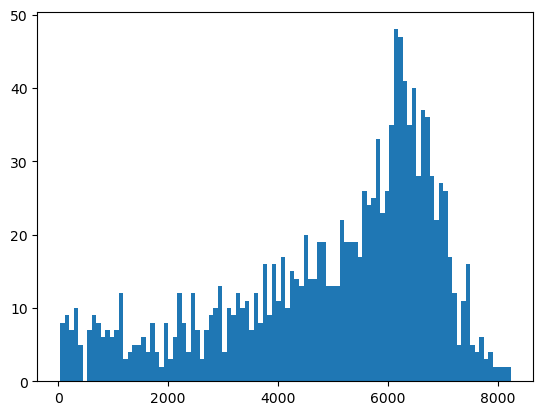

In [27]:
plt.figure()
plt.hist(df.N, 100);
plt.gca().set_xlabel('number of crossovers per rgt')

In [28]:
# filter out rgts that have fewer than 1000 xovers

In [ ]:
df = df[df['N'] >1000].reset_index(drop=True)

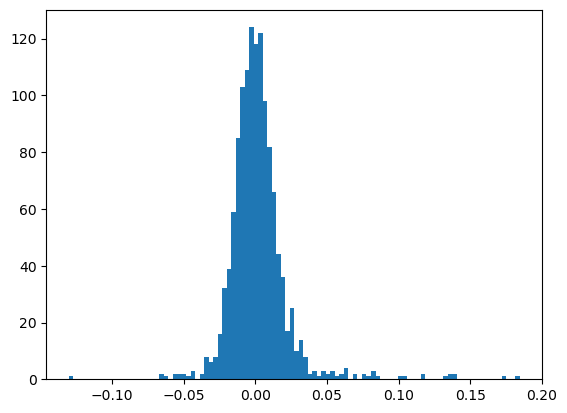

In [29]:
hf, hax=plt.subplots(1, 2, figsize=[10,5])
plt.sca(hax[0])
plt.hist(df['med'], 100);
plt.gca().set_xlabel('per-track median(dh), m')
plt.sca(hax[1])
plt.hist(df['sigma_hat'], 100);
plt.gca().set_xlabel('per-track spread(dh), m')

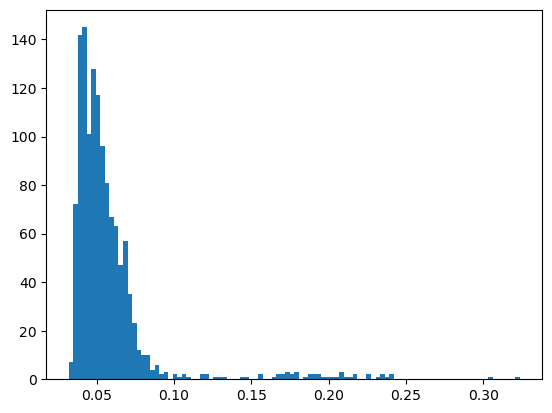

In [30]:
plt.figure()


In [ ]:
# plot median vs. spread:

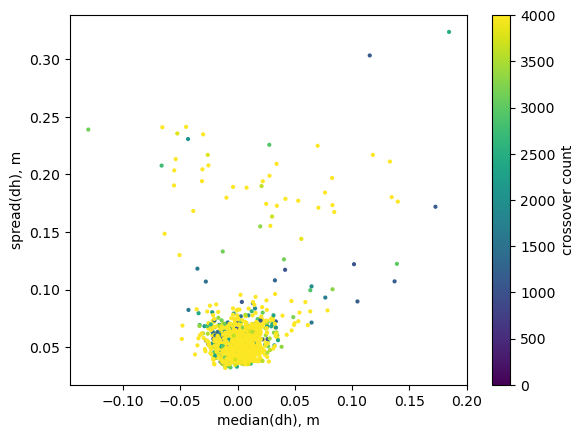

In [50]:
hs = plt.scatter(df['med'], df['sigma_hat'],4, c=df['N'], clim=[0, 4000])
plt.gca().set_xlabel('median(dh), m')
plt.gca().set_ylabel('spread(dh), m')
plt.colorbar(hs, label='crossover count')

# outlier RGTs:

In [58]:
bads = np.array((np.abs(df['med']) > 0.05) | (df['sigma_hat'] > 0.15))
np.array(df.rgt)[np.flatnonzero(bads)]

array([   4,   32,   57,   84,   99,  101,  102,  117,  142,  159,  178,
        186,  205,  218,  236,  239,  255,  261,  280,  304,  315,  328,
        354,  388,  466,  481,  482,  496,  497,  498,  499,  503,  509,
        521,  557,  574,  583,  606,  617,  646,  651,  652,  653,  657,
        685,  697,  708,  722,  757,  767,  780,  802,  812,  829,  849,
        971, 1108, 1109, 1150, 1151, 1152])

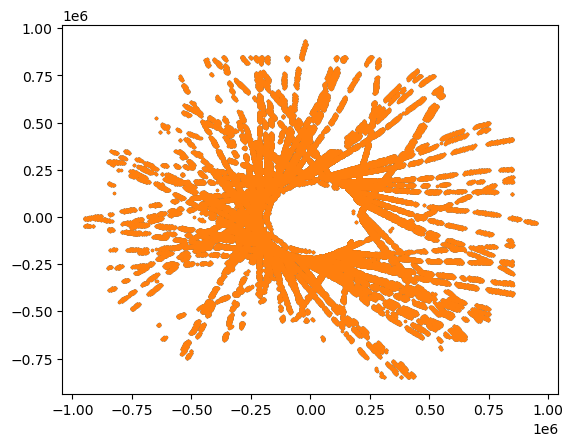

In [68]:
bad_rgts = np.array(df.rgt)[np.flatnonzero(bads)]

plt.figure()
these = np.flatnonzero(np.any(np.isin(v.rgt, bad_rgts), axis=1))
plt.plot(v.x[these,:], v.y[these,:],'.', markersize=3)

# worst track, by spread:

In [35]:
worst = df.rgt[np.argmax(df.sigma_hat)]

In [36]:
worst

np.int64(497)

In [51]:
# the worst rgt in cycle 28 is 497.  We can look for it on css: (this takes a minute)
! ls /css/icesat-2/ATLAS/ATL06.007/*/*04972811*

/css/icesat-2/ATLAS/ATL06.007/2025.07.18/ATL06_20250718074758_04972811_007_01.h5


# plots of that worst RGT:

In [38]:
D=pc.ATL06.data(beam_pair=2).from_h5('/css/icesat-2/ATLAS/ATL06.007/2025.07.18/ATL06_20250718074758_04972811_007_01.h5')
D.get_xy(3031)

Text(0, 0.5, 'h_li, m')

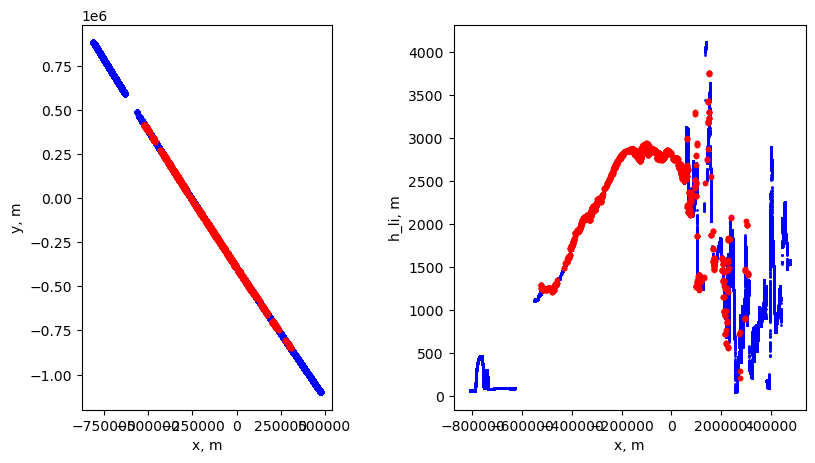

In [52]:
hf, hax=plt.subplots(1, 2, figsize=[10,5])
plt.sca(hax[0])
plt.plot(D.x, D.y,'b.', label='all ATL06 points')
these = np.any(v.rgt==worst, axis=1)
plt.plot(v.x[these], v.y[these],'r.', label='crossover points')
plt.gca().set_aspect(1)
plt.gca().set_xlabel('x, m')
plt.gca().set_ylabel('y, m')

plt.sca(hax[1])
D.h_li[D.atl06_quality_summary>0]=np.nan
plt.plot(D.x, D.h_li,'b.', markersize=2)
these = np.any(v.rgt==worst, axis=1)
plt.plot(v.x[these], v.h_li[these],'r.')
plt.gca().set_xlabel('x, m')
plt.gca().set_ylabel('h_li, m')


In the case of cycle 28, the worst RGT is one that happens to hit the transiantarctic mountains.
